# Exercise 7.10
Devise a small off-policy prediction problem and use it to show that the off-policy learning algorithm using (7.13) and (7.2) is more data e cient than the simpler algorithm using (7.1) and (7.9).

In this assignment, we will use Frozen Lake env from OpenAI Gymnasium library.

### Part1:

Since the agent is moving over a frozen surface, it may not go into the intended direction. In this part, we will create non-slippery environment to avoid the uncertain moves.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
random_seed = 1234

#Environment 
env = gym.make("FrozenLake-v1", is_slippery=False) # when you test non-slippery you can set is_slippery=False; I removed the result of the test for the nonslippery one
n_states = env.observation_space.n
n_actions = env.action_space.n
gamma = 0.99



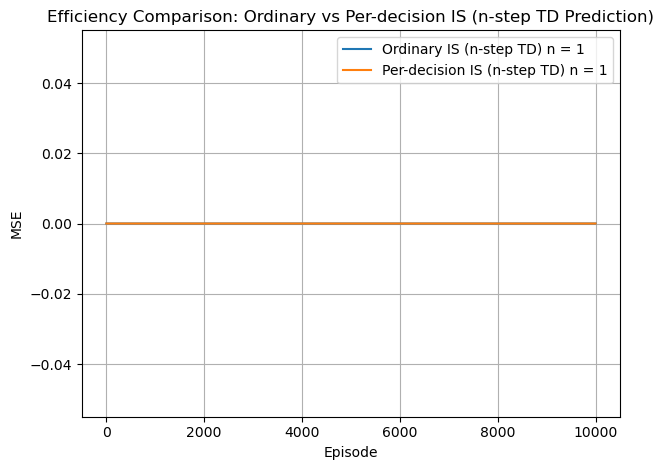

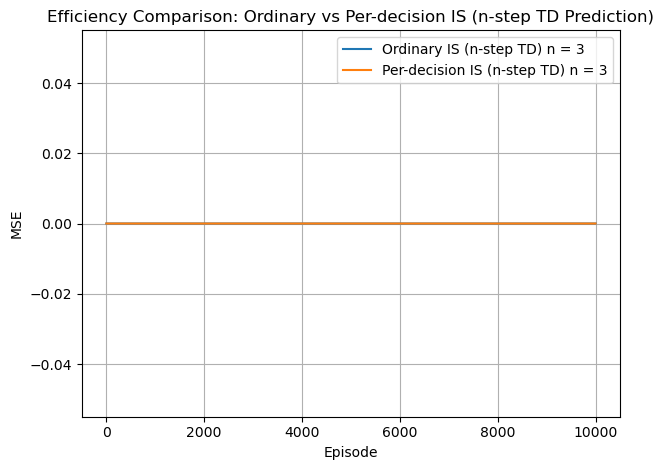

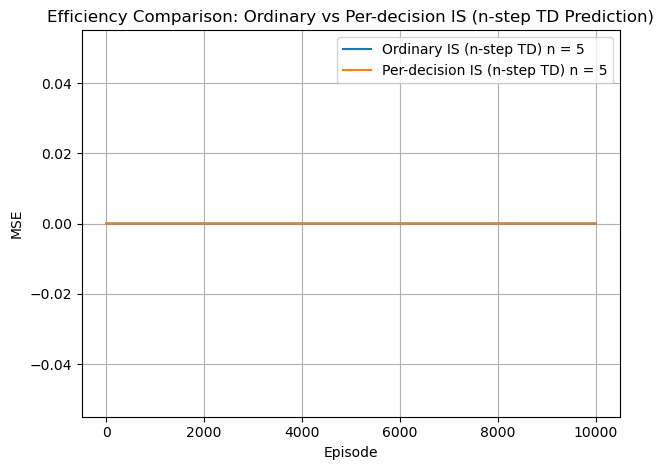

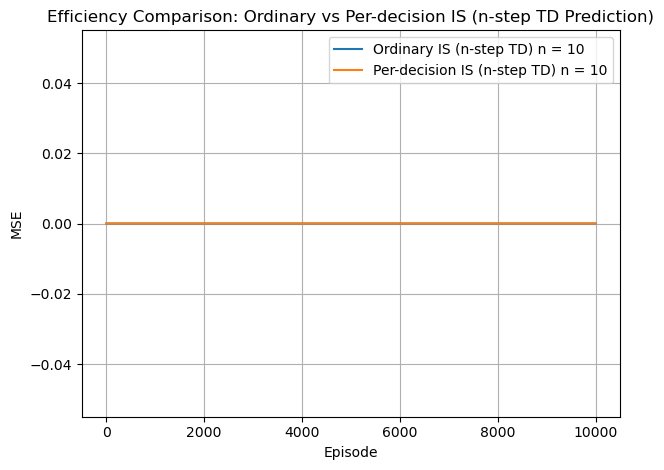

In [ ]:
def mc_control_glie(env, n_episodes=50000, gamma=0.99, epsilon=0.1):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    returns_sum = np.zeros((n_states, n_actions))
    returns_count = np.zeros((n_states, n_actions))

    for ep in range(n_episodes):
        episode = []
        state, _ = env.reset()
        done = False

        while not done:
            if np.random.rand() < epsilon:
                action = np.random.choice(n_actions)
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r
            if (s, a) not in visited:
                returns_sum[s][a] += G
                returns_count[s][a] += 1
                Q[s][a] = returns_sum[s][a] / returns_count[s][a]
                visited.add((s, a))
    
    return Q

def learned_target_policy(Q):
    def policy_fn(state):
        return np.argmax(Q[state])
    return policy_fn


Q_mc = mc_control_glie(env, n_episodes=50000, epsilon=0.2)
target_policy = learned_target_policy(Q_mc) 



# Behavior policy
def behavior_policy(state):
    return np.random.choice(n_actions)  

# Importance ratio
def get_rho(behavior_action, target_action):
    return 1.0 if behavior_action == target_action else 0.0

# True V estimate using MC 
def estimate_true_V_mc(env, policy, n_states, n_sim=10000):
    true_V = np.zeros(n_states)
    for s in range(n_states):
        Gs = []
        for _ in range(n_sim):
            _, _ = env.reset()
            env.env.s = s
            state = s
            done = False
            G = 0
            discount = 1.0
            while not done:
                a = policy(state)
                next_state, reward, terminated, truncated, _ = env.step(a)
                done = terminated or truncated
                G += discount * reward
                discount *= gamma
                state = next_state
            Gs.append(G)
        true_V[s] = np.mean(Gs)
    return true_V

# Ordinary td
def td_IS(n_episodes, n_step, true_V):
    V = np.zeros(n_states)
    errors = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        states, actions, rewards = [], [], []
        done = False
        T = float('inf')
        t = 0

        while True:
            if t < T:
                action = behavior_policy(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                states.append(state)
                actions.append(action)
                rewards.append(reward)
                state = next_state
                if terminated or truncated:
                    T = t + 1

            tau = t - n_step + 1
            if tau >= 0:
                G = 0.0
                W = 1.0
                for i in range(tau, min(tau + n_step, T)):
                    G += (gamma ** (i - tau)) * rewards[i]
                if tau + n_step < T and (tau + n_step) < len(states):
                    G += (gamma ** n_step) * V[states[tau + n_step]]
                for i in range(tau, min(tau + n_step, T)):
                    W *= get_rho(actions[i], target_policy(states[i]))
                s_tau = states[tau]
                V[s_tau] += 0.1 * W * (G - V[s_tau])  # α = 0.1

            t += 1
            if tau >= T - 1:
                break
        errors.append(np.mean((V - true_V) ** 2))
    return V, errors

# Per-decision 
def per_decision_IS(n_episodes, n_step, true_V):
    V = np.zeros(n_states)
    errors = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        states, actions, rewards = [], [], []
        done = False
        T = float('inf')
        t = 0

        while True:
            if t < T:
                action = behavior_policy(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                states.append(state)
                actions.append(action)
                rewards.append(reward)
                state = next_state
                if terminated or truncated:
                    T = t + 1

            tau = t - n_step + 1
            if tau >= 0:
                G = 0.0
                rho = 1.0
                for i in range(tau, min(tau + n_step, T)):
                    G += (gamma ** (i - tau)) * rewards[i]
                    rho *= get_rho(actions[i], target_policy(states[i]))
                if tau + n_step < T and (tau + n_step) < len(states):
                    G += (gamma ** n_step) * V[states[tau + n_step]]
                s_tau = states[tau]
                V[s_tau] += 0.1 * rho * (G - V[s_tau])  # α = 0.1

            t += 1
            if tau >= T - 1:
                break
        errors.append(np.mean((V - true_V) ** 2))
    return V, errors

#test
n_episodes = 10000
# n_step = 3 
true_V = estimate_true_V_mc(env, target_policy, n_states, n_sim=10000)


for n in [1, 3, 5, 10]:

    V1, errors1 = td_IS(n_episodes, n, true_V)
    V2, errors2 = per_decision_IS(n_episodes, n, true_V)

    plt.plot(errors1, label=f"Ordinary IS (n-step TD) n = {n}")
    plt.plot(errors2, label=f"Per-decision IS (n-step TD) n = {n}")
    plt.title("Efficiency Comparison: Ordinary vs Per-decision IS (n-step TD Prediction)")

    plt.xlabel("Episode")
    plt.ylabel("MSE")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    



# Part2： Non-slippery Environment

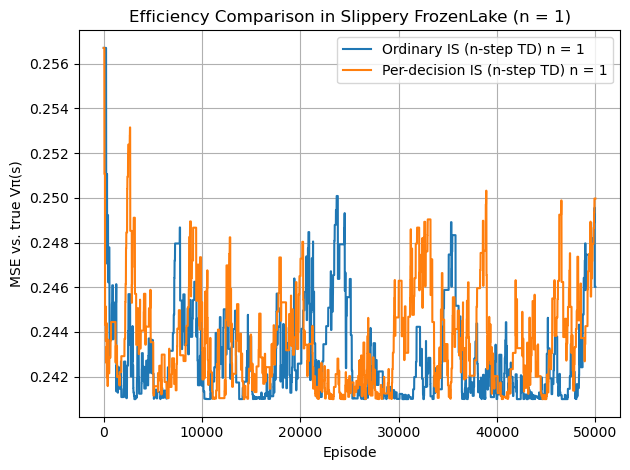

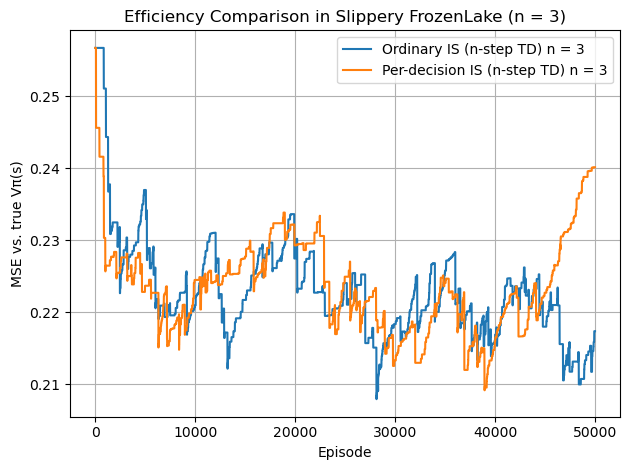

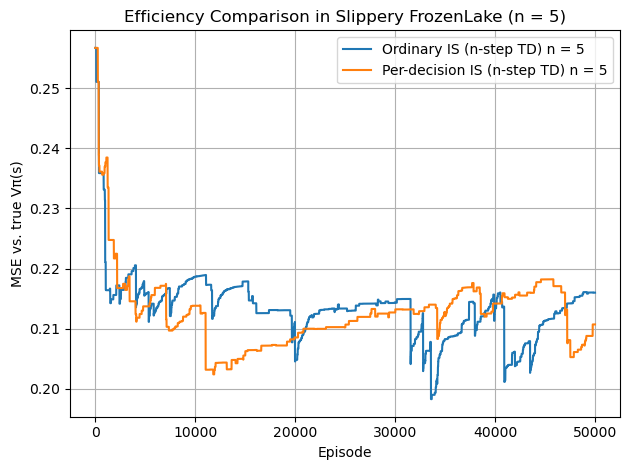

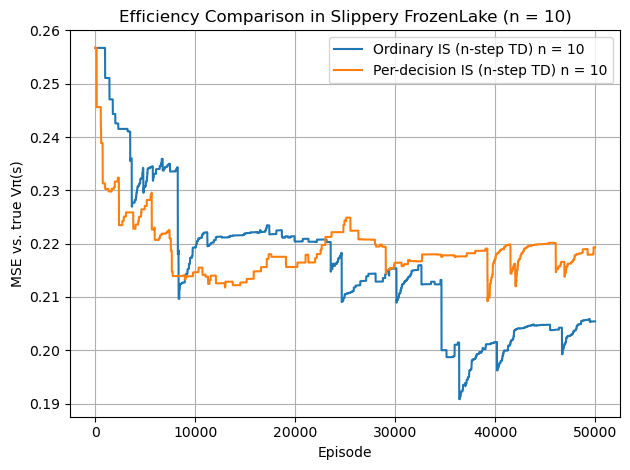

In [4]:
#test non-slippery part
slippery_env = gym.make("FrozenLake-v1", is_slippery=True)
n_states = slippery_env.observation_space.n
n_actions = slippery_env.action_space.n
gamma = 0.99


def mc_control_glie(env, n_episodes=50000, gamma=0.99, epsilon=0.1):
    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    returns_sum = np.zeros((n_states, n_actions))
    returns_count = np.zeros((n_states, n_actions))

    for ep in range(n_episodes):
        episode = []
        state, _ = env.reset()
        done = False

        while not done:
            # ε-greedy action 
            if np.random.rand() < epsilon:
                action = np.random.choice(n_actions)
            else:
                action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            done = terminated or truncated

        G = 0
        visited = set()
        for t in reversed(range(len(episode))):
            s, a, r = episode[t]
            G = gamma * G + r
            if (s, a) not in visited:
                returns_sum[s][a] += G
                returns_count[s][a] += 1
                Q[s][a] = returns_sum[s][a] / returns_count[s][a]
                visited.add((s, a))
    
    return Q

def learned_target_policy(Q):
    def policy_fn(state):
        return np.argmax(Q[state])
    return policy_fn

Q_mc_slippery = mc_control_glie(slippery_env, n_episodes=50000, epsilon=0.2)
target_policy_slippery = learned_target_policy(Q_mc_slippery)


def behavior_policy(state):
    return np.random.choice(n_actions)

def get_rho(behavior_action, target_action):
    return 1.0 if behavior_action == target_action else 0.0

def estimate_true_V_mc(env, policy, n_states, n_sim=10000):
    true_V = np.zeros(n_states)
    for s in range(n_states):
        Gs = []
        for _ in range(n_sim):
            _, _ = env.reset()
            env.env.s = s
            state = s
            done = False
            G = 0
            discount = 1.0
            while not done:
                a = policy(state)
                next_state, reward, terminated, truncated, _ = env.step(a)
                done = terminated or truncated
                G += discount * reward
                discount *= gamma
                state = next_state
            Gs.append(G)
        true_V[s] = np.mean(Gs)
    return true_V

# Ordinary TD 
def td_IS(env, n_episodes, n_step, true_V, target_policy):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    errors = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        states, actions, rewards = [], [], []
        done = False
        T = float('inf')
        t = 0

        while True:
            if t < T:
                action = behavior_policy(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                states.append(state)
                actions.append(action)
                rewards.append(reward)
                state = next_state
                if terminated or truncated:
                    T = t + 1

            tau = t - n_step + 1
            if tau >= 0:
                G = 0.0
                W = 1.0
                for i in range(tau, min(tau + n_step, T)):
                    G += (gamma ** (i - tau)) * rewards[i]
                if tau + n_step < T and (tau + n_step) < len(states):
                    G += (gamma ** n_step) * V[states[tau + n_step]]
                for i in range(tau, min(tau + n_step, T)):
                    W *= get_rho(actions[i], target_policy(states[i]))
                s_tau = states[tau]
                V[s_tau] += 0.1 * W * (G - V[s_tau])  # α = 0.1

            t += 1
            if tau >= T - 1:
                break
        errors.append(np.mean((V - true_V) ** 2))
    return V, errors

# Per-decision IS 
def per_decision_IS(env, n_episodes, n_step, true_V, target_policy):
    n_states = env.observation_space.n
    V = np.zeros(n_states)
    errors = []

    for ep in range(n_episodes):
        state, _ = env.reset()
        states, actions, rewards = [], [], []
        done = False
        T = float('inf')
        t = 0

        while True:
            if t < T:
                action = behavior_policy(state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                states.append(state)
                actions.append(action)
                rewards.append(reward)
                state = next_state
                if terminated or truncated:
                    T = t + 1

            tau = t - n_step + 1
            if tau >= 0:
                G = 0.0
                rho = 1.0
                for i in range(tau, min(tau + n_step, T)):
                    G += (gamma ** (i - tau)) * rewards[i]
                    rho *= get_rho(actions[i], target_policy(states[i]))
                if tau + n_step < T and (tau + n_step) < len(states):
                    G += (gamma ** n_step) * V[states[tau + n_step]]
                s_tau = states[tau]
                V[s_tau] += 0.1 * rho * (G - V[s_tau])  # α = 0.1

            t += 1
            if tau >= T - 1:
                break
        errors.append(np.mean((V - true_V) ** 2))
    return V, errors

#test slippery part
n_episodes = 50000
true_V_slippery = estimate_true_V_mc(slippery_env, target_policy_slippery, n_states, n_sim=10000)

for n in [1, 3, 5, 10]:
    V1, errors1 = td_IS(slippery_env, n_episodes, n, true_V_slippery, target_policy_slippery)
    V2, errors2 = per_decision_IS(slippery_env, n_episodes, n, true_V_slippery, target_policy_slippery)
    
    plt.figure()
    plt.plot(errors1, label=f"Ordinary IS (n-step TD) n = {n}")
    plt.plot(errors2, label=f"Per-decision IS (n-step TD) n = {n}")
    plt.title(f"Efficiency Comparison in Slippery FrozenLake (n = {n})")
    plt.xlabel("Episode")
    plt.ylabel("MSE vs. true Vπ(s)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
